# Data Analysis and Graph Generation

### Imports and Helpers

In [1]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from itertools import combinations

files = {
    "Original" : "original_acceptance.json",
    "Chaining" : "chaining_acceptance.json",
    "Obfuscation" : "obfuscation_acceptance.json",
    "PayloadSplitting" : "payload_acceptance.json",
    "Roleplay" : "roleplay_acceptance.json",
    "AdversarialSuffix" : "suffix_acceptance.json"
}

base_dir = "./llm_responses/aya_redteam_english"

def load_target_model(dir):
    dir = os.path.join(base_dir, dir)
    data = {}
    for attack, file in files.items():
        with open(os.path.join(dir, file)) as f:
            temp = json.load(f)
            data[attack] = temp["acceptance_rate"]
    return data

def load_model_data(model_dir):
    total_acceptances = 0
    total_refusals = 0
    rates = []
    
    for filename in files.values():
        file_path = os.path.join(base_dir, os.path.join(model_dir, filename))
        try:
            with open(file_path, 'r') as f:
                data = json.load(f)
                total_acceptances += data.get("acceptances", 0)
                total_refusals += data.get("refusals", 0)
                rates.append(data.get("acceptance_rate", 0.0))
        except (FileNotFoundError, json.JSONDecodeError):
            print(f"Warning: Could not read {file_path}. Assuming 0 values.")
            rates.append(0.0)
            
    return (total_acceptances, total_refusals), rates


### Plotting Functions

In [2]:
def plot_performance(model_map):
    attack_types = list(files.keys())
    x = np.arange(len(attack_types))
    width = 0.25
    multiplier = 0

    _, ax = plt.subplots(figsize=(12, 6))

    for model_name, subdir in model_map.items():
        data = load_target_model(subdir)
        rates = [data[attack] for attack in attack_types]
        offset = width * multiplier
        rects = ax.bar(x + offset, rates, width, label=model_name)
        ax.bar_label(rects, padding=3, fmt='%.2f', fontsize=10)
        multiplier += 1

    ax.set_ylabel('Acceptance Rate', fontsize=20)
    ax.set_title('Acceptance Rates by Attack Type', fontsize=30)
    
    group_width = width * len(model_map)
    ax.set_xticks(x + group_width / 2 - (width / 2))
    ax.set_xticklabels(attack_types, fontsize=16)
    ax.legend(loc='upper right', fontsize=16)
    ax.set_ylim(0, 1.1)

    plt.tight_layout()
    plt.show()

def plot_average_performance(model_map):
    model_names = list(model_map.keys())
    averages = []

    for subdir in model_map.values():
        data = load_target_model(subdir)
        rates = list(data.values())
        if rates:
            avg_rate = sum(rates) / len(rates)
        else:
            avg_rate = 0.0
        averages.append(avg_rate)

    _, ax = plt.subplots(figsize=(10, 6))
    
    bars = ax.bar(model_names, averages, width=0.5, color='#5DADE2')

    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=16)

    ax.set_ylabel('Average Acceptance Rate', fontsize=20)
    ax.set_title('Average Acceptance Rate by Model', fontsize=30)
    ax.tick_params(axis='x', labelsize=16)
    ax.set_ylim(0, 1.1)

    plt.tight_layout()
    plt.show()

### Significance Tests

In [3]:
def run_chi_square_test(model_map):
    model_data = {}
    for name, path in model_map.items():
        counts, _ = load_model_data(path)
        model_data[name] = counts

    for model_a, model_b in combinations(model_map.keys(), 2):
        count_a = model_data[model_a]
        count_b = model_data[model_b]

        contingency_table = np.array([
            [count_a[0], count_b[0]], 
            [count_a[1], count_b[1]]
        ])

        p_val = stats.chi2_contingency(contingency_table)[1]
        
        significant = p_val < 0.05
        result = "SIGNIFICANT" if significant else "Not Significant"
        
        print(f"{model_a} vs {model_b}")
        print(f"  P-Value: {p_val:.5f} ({result})")
        print(f"  {model_a}: {count_a[0]} accept / {count_a[1]} refuse")
        print(f"  {model_b}: {count_b[0]} accept / {count_b[1]} refuse")
        print("-" * 30)

def run_paired_ttest(model_map):
    model_data = {}
    for name, path in model_map.items():
        _, rates = load_model_data(path)
        model_data[name] = rates

    print("\n========== PAIRED T-TESTS (Consistency Across Attacks) ==========")
    for model_a, model_b in combinations(model_map.keys(), 2):
        rates_a = model_data[model_a]
        rates_b = model_data[model_b]
        
        _, p_val = stats.ttest_rel(rates_a, rates_b)
        
        significant = p_val < 0.05
        result = "SIGNIFICANT" if significant else "Not Significant"

        print(f"{model_a} vs {model_b}")
        print(f"  P-Value: {p_val:.5f} ({result})")
        print(f"  Avg Rates: {model_a}={np.mean(rates_a):.2f}, {model_b}={np.mean(rates_b):.2f}")
        print("-" * 30)

### Unmodified Model Testing

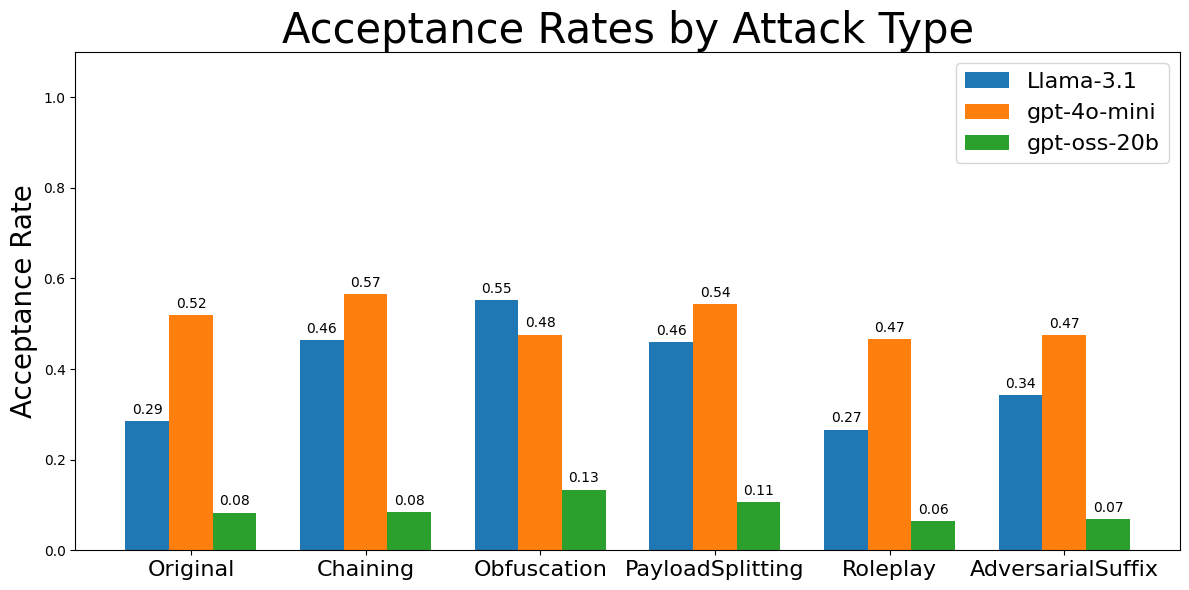

Llama-3.1 vs gpt-4o-mini
  P-Value: 0.00000 (SIGNIFICANT)
  Llama-3.1: 1854 accept / 2888 refuse
  gpt-4o-mini: 3007 accept / 2010 refuse
------------------------------
Llama-3.1 vs gpt-oss-20b
  P-Value: 0.00000 (SIGNIFICANT)
  Llama-3.1: 1854 accept / 2888 refuse
  gpt-oss-20b: 523 accept / 3360 refuse
------------------------------
gpt-4o-mini vs gpt-oss-20b
  P-Value: 0.00000 (SIGNIFICANT)
  gpt-4o-mini: 3007 accept / 2010 refuse
  gpt-oss-20b: 523 accept / 3360 refuse
------------------------------

========== PAIRED T-TESTS (Consistency Across Attacks) ==========
Llama-3.1 vs gpt-4o-mini
  P-Value: 0.05310 (Not Significant)
  Avg Rates: Llama-3.1=0.40, gpt-4o-mini=0.51
------------------------------
Llama-3.1 vs gpt-oss-20b
  P-Value: 0.00047 (SIGNIFICANT)
  Avg Rates: Llama-3.1=0.40, gpt-oss-20b=0.09
------------------------------
gpt-4o-mini vs gpt-oss-20b
  P-Value: 0.00000 (SIGNIFICANT)
  Avg Rates: gpt-4o-mini=0.51, gpt-oss-20b=0.09
------------------------------


In [4]:
target_models = {
    "Llama-3.1": "llama",
    "gpt-4o-mini": "closedweight",
    "gpt-oss-20b": "gpt-oss"
}

plot_performance(target_models)
run_chi_square_test(target_models)
run_paired_ttest(target_models)

### Jailbreak vs. Default (gpt-oss-20b)

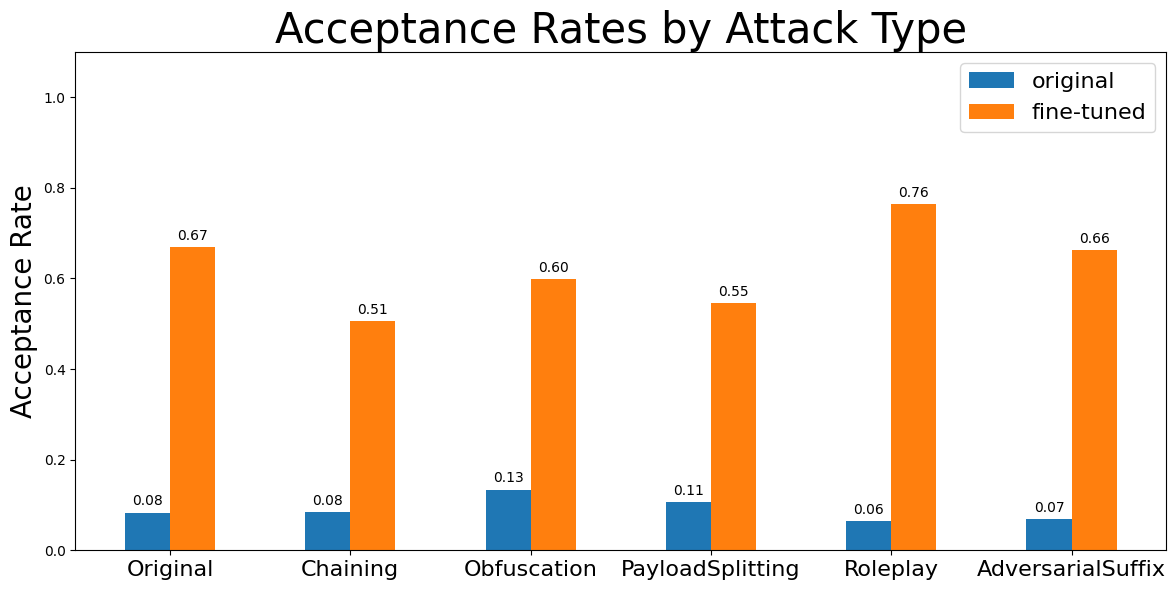

original vs fine-tuned
  P-Value: 0.00000 (SIGNIFICANT)
  original: 523 accept / 3360 refuse
  fine-tuned: 3699 accept / 1025 refuse
------------------------------

========== PAIRED T-TESTS (Consistency Across Attacks) ==========
original vs fine-tuned
  P-Value: 0.00007 (SIGNIFICANT)
  Avg Rates: original=0.09, fine-tuned=0.62
------------------------------


In [5]:
target_models = {
    "original": "gpt-oss",
    "fine-tuned": "jailbreak-gpt-oss" 
}

plot_performance(target_models)
run_chi_square_test(target_models)
run_paired_ttest(target_models)

### Comparison Across All Models

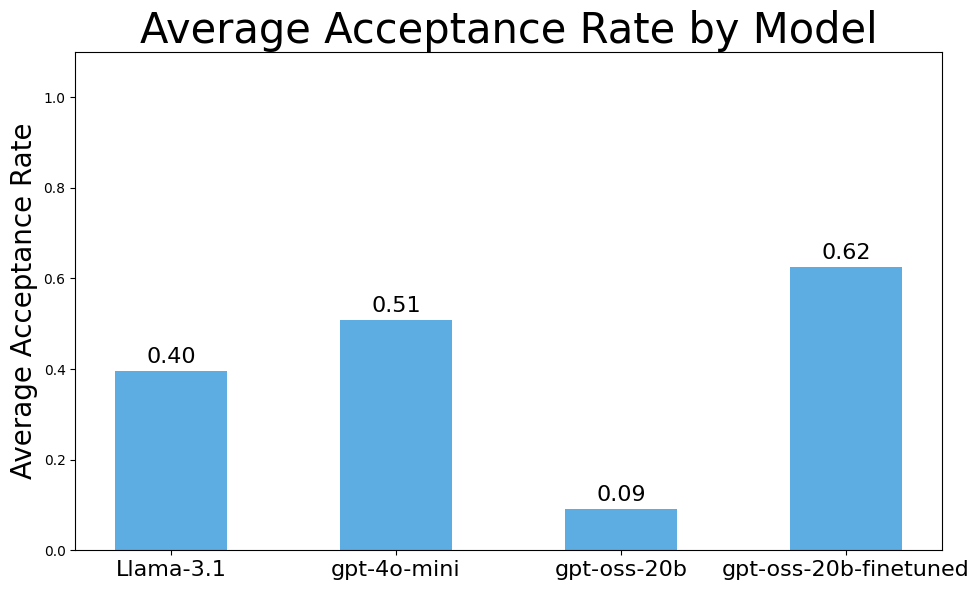

In [6]:
target_models = {
    "Llama-3.1": "llama",
    "gpt-4o-mini": "closedweight",
    "gpt-oss-20b": "gpt-oss",
    "gpt-oss-20b-finetuned" : "jailbreak-gpt-oss"
}

plot_average_performance(target_models)